# Scan-phase comparison: v2-7-7 vs current

Loads `D:\scanphase_versions\v2-7-7.json` and `D:\scanphase_versions\current.json` (produced by the two sibling notebooks) and answers:

1. **Which version is more accurate?** Using current's FFT-subpixel estimate at the largest window as the best-available ground truth, measure bias of every other (version, use_fft, window) combination against it.
2. **Which version is faster, and by how much?** Per-window speedup factors and absolute timings.
3. **Do offsets differ across window sizes?** Side-by-side table.
4. **Is the FFT variant of each version faster or slower than its integer variant?**
5. **Frame-to-frame stability** (per-frame estimator) - tighter std = lower noise = more accurate estimator on a single frame.

Run this in any kernel that has `numpy` + `matplotlib` (the current `mbo_utilities/.venv` works fine).

In [1]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

SAVE_DIR = Path(r"D:\scanphase_versions")
OLD_PATH = SAVE_DIR / "v2-7-7.json"
NEW_PATH = SAVE_DIR / "current.json"

old = json.loads(OLD_PATH.read_text())
new = json.loads(NEW_PATH.read_text())

print(f"OLD  {OLD_PATH.name}  pkg_versions={old['package_versions']}")
print(f"NEW  {NEW_PATH.name}  pkg_versions={new['package_versions']}")
print(f"chunk_shape OLD={old['chunk_shape']}  NEW={new['chunk_shape']}  match={old['chunk_shape']==new['chunk_shape']}")

OLD  v2-7-7.json  pkg_versions={'mbo_utilities': '2.7.7', 'numpy': '2.3.5', 'scipy': '1.17.1', 'scikit-image': '0.26.0'}
NEW  current.json  pkg_versions={'mbo_utilities': '3.0.0', 'numpy': '2.3.5', 'scipy': '1.17.1', 'scikit-image': '0.26.0'}
chunk_shape OLD=[500, 550, 448]  NEW=[500, 550, 448]  match=True


In [2]:
def index_results(payload):
    """return dict keyed by (window_size, use_fft) for the windowed runs,
    plus a separate per-frame dict.
    """
    windowed = {}
    per_frame = {}
    for r in payload["results"]:
        if r["window_size"] == "per_frame":
            per_frame[bool(r["use_fft"])] = r
        else:
            windowed[(int(r["window_size"]), bool(r["use_fft"]))] = r
    return windowed, per_frame

old_w, old_pf = index_results(old)
new_w, new_pf = index_results(new)

WINDOWS = sorted({k[0] for k in old_w} | {k[0] for k in new_w})
USE_FFT = [False, True]
print(f"window sizes: {WINDOWS}")
print(f"use_fft variants: {USE_FFT}")

window sizes: [1, 10, 100, 200, 500]
use_fft variants: [False, True]


## 1. Calculated offsets across window sizes

Side-by-side. If the offsets converge to the same value at large windows, both estimators are unbiased; if they diverge persistently, one has a systematic bias.

In [3]:
def get_offset(rec):
    o = rec["offset"]
    return float(o) if not isinstance(o, list) else float(np.asarray(o).mean())

print(f"{'win':>5}  {'use_fft':>7}  {'OLD offset':>12}  {'NEW offset':>12}  {'delta':>10}")
print("-" * 60)
for use_fft in USE_FFT:
    for w in WINDOWS:
        o = get_offset(old_w[(w, use_fft)])
        n = get_offset(new_w[(w, use_fft)])
        print(f"{w:>5d}  {str(use_fft):>7s}  {o:>12.4f}  {n:>12.4f}  {n - o:>+10.4f}")
    print()

  win  use_fft    OLD offset    NEW offset       delta
------------------------------------------------------------
    1    False        0.0000        1.0000     +1.0000
   10    False        1.0000        1.0000     +0.0000
  100    False        1.0000        1.0000     +0.0000
  200    False        1.0000        1.0000     +0.0000
  500    False        1.0000        1.0000     +0.0000

    1     True        0.5000        0.8404     +0.3404
   10     True        0.7500        0.7705     +0.0205
  100     True        0.7500        0.9781     +0.2281
  200     True        0.7500        0.9495     +0.1995
  500     True        0.7500        0.9568     +0.2068



## 2. Speed: median runtime per (version, window, use_fft)

In [4]:
print(f"{'win':>5}  {'use_fft':>7}  {'OLD ms':>10}  {'NEW ms':>10}  {'speedup':>10}  {'NEW vs OLD':>14}")
print("-" * 70)
for use_fft in USE_FFT:
    for w in WINDOWS:
        ot = old_w[(w, use_fft)]["time_ms_median"]
        nt = new_w[(w, use_fft)]["time_ms_median"]
        speedup = ot / nt if nt else float("inf")
        verdict = "NEW faster" if nt < ot else "OLD faster" if ot < nt else "tied"
        print(f"{w:>5d}  {str(use_fft):>7s}  {ot:>10.2f}  {nt:>10.2f}  {speedup:>10.2f}x  {verdict:>14s}")
    print()

  win  use_fft      OLD ms      NEW ms     speedup      NEW vs OLD
----------------------------------------------------------------------
    1    False       13.68        4.47        3.06x      NEW faster
   10    False       10.87        4.25        2.55x      NEW faster
  100    False       39.46       30.55        1.29x      NEW faster
  200    False       63.72       58.03        1.10x      NEW faster
  500    False      147.30      144.00        1.02x      NEW faster

    1     True       23.13        2.72        8.50x      NEW faster
   10     True      142.07       16.90        8.41x      NEW faster
  100     True     1336.69      149.85        8.92x      NEW faster
  200     True     2683.82      295.17        9.09x      NEW faster
  500     True     6407.17      762.80        8.40x      NEW faster



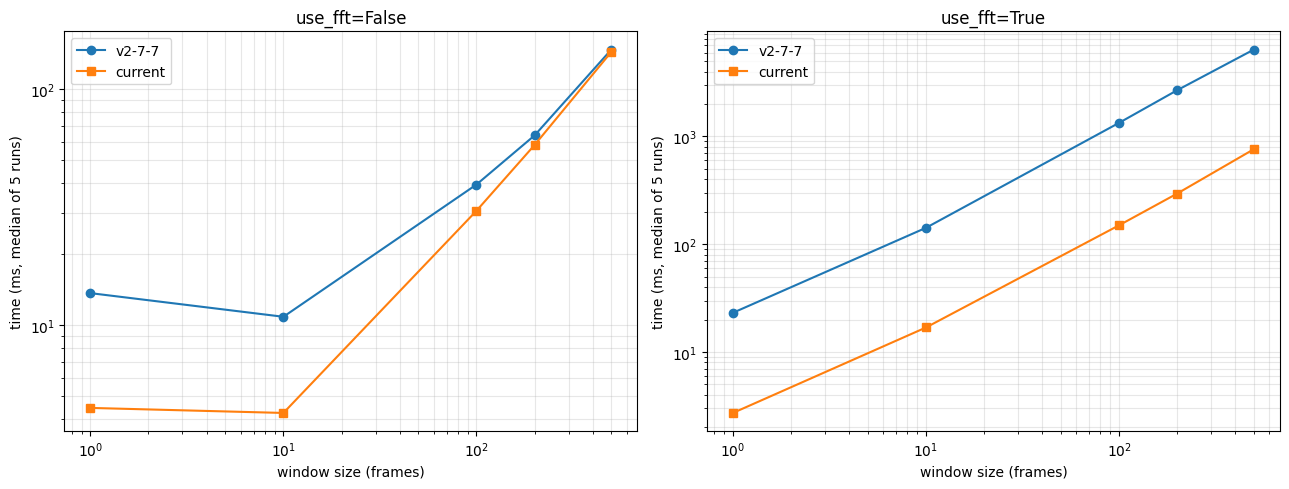

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, use_fft in zip(axs, USE_FFT):
    old_t = [old_w[(w, use_fft)]["time_ms_median"] for w in WINDOWS]
    new_t = [new_w[(w, use_fft)]["time_ms_median"] for w in WINDOWS]
    ax.plot(WINDOWS, old_t, "o-", label="v2-7-7", color="C0")
    ax.plot(WINDOWS, new_t, "s-", label="current", color="C1")
    ax.set_xlabel("window size (frames)")
    ax.set_ylabel("time (ms, median of 5 runs)")
    ax.set_title(f"use_fft={use_fft}")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
plt.tight_layout(); plt.show()

## 3. Accuracy: bias from gold standard

Gold standard = current's FFT-subpixel offset at the largest window (most data, most precision available). The new code's own comment notes the v2-7-7 integer estimator was biased by ±2-3 px when truth was ~1 px - we should see this directly here.

In [6]:
GOLD_WIN = max(WINDOWS)
gold = get_offset(new_w[(GOLD_WIN, True)])
print(f"gold standard: NEW use_fft=True window={GOLD_WIN} -> offset={gold:.4f}")
print()
print(f"{'version':>10}  {'use_fft':>7}  {'win':>5}  {'offset':>10}  {'|bias|':>10}  {'note'}")
print("-" * 78)
for label, src in (("v2-7-7", old_w), ("current", new_w)):
    for use_fft in USE_FFT:
        for w in WINDOWS:
            o = get_offset(src[(w, use_fft)])
            bias = abs(o - gold)
            tag = "GOLD" if (label == "current" and use_fft and w == GOLD_WIN) else ""
            print(f"{label:>10s}  {str(use_fft):>7s}  {w:>5d}  {o:>10.4f}  {bias:>10.4f}  {tag}")
    print()

gold standard: NEW use_fft=True window=500 -> offset=0.9568

   version  use_fft    win      offset      |bias|  note
------------------------------------------------------------------------------
    v2-7-7    False      1      0.0000      0.9568  
    v2-7-7    False     10      1.0000      0.0432  
    v2-7-7    False    100      1.0000      0.0432  
    v2-7-7    False    200      1.0000      0.0432  
    v2-7-7    False    500      1.0000      0.0432  
    v2-7-7     True      1      0.5000      0.4568  
    v2-7-7     True     10      0.7500      0.2068  
    v2-7-7     True    100      0.7500      0.2068  
    v2-7-7     True    200      0.7500      0.2068  
    v2-7-7     True    500      0.7500      0.2068  

   current    False      1      1.0000      0.0432  
   current    False     10      1.0000      0.0432  
   current    False    100      1.0000      0.0432  
   current    False    200      1.0000      0.0432  
   current    False    500      1.0000      0.0432  
   curr

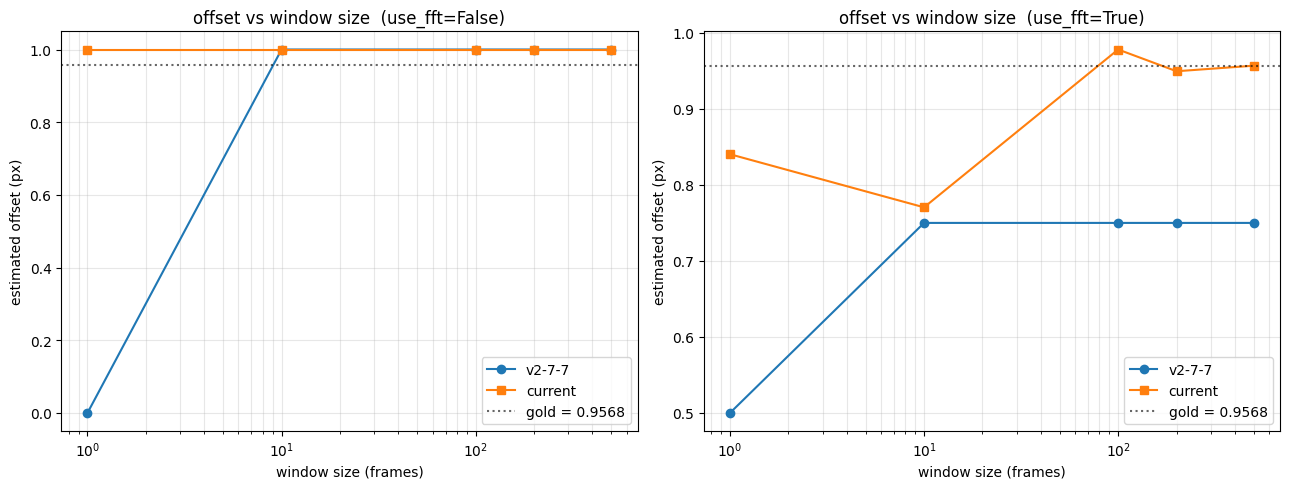

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, use_fft in zip(axs, USE_FFT):
    old_off = [get_offset(old_w[(w, use_fft)]) for w in WINDOWS]
    new_off = [get_offset(new_w[(w, use_fft)]) for w in WINDOWS]
    ax.plot(WINDOWS, old_off, "o-", label="v2-7-7", color="C0")
    ax.plot(WINDOWS, new_off, "s-", label="current", color="C1")
    ax.axhline(gold, ls=":", color="black", alpha=0.6, label=f"gold = {gold:.4f}")
    ax.set_xlabel("window size (frames)")
    ax.set_ylabel("estimated offset (px)")
    ax.set_title(f"offset vs window size  (use_fft={use_fft})")
    ax.set_xscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
plt.tight_layout(); plt.show()

## 4. Frame-to-frame stability (per-frame estimator)

Run on every frame independently (`method='frame'`). A more accurate estimator should produce a tighter distribution (lower std) since the underlying scan-phase offset is roughly constant within a recording.

In [8]:
print(f"{'version':>10}  {'use_fft':>7}  {'mean':>10}  {'std':>10}  {'min':>10}  {'max':>10}  {'ms/frame':>10}")
print("-" * 80)
for label, pf in (("v2-7-7", old_pf), ("current", new_pf)):
    for use_fft in USE_FFT:
        rec = pf.get(use_fft)
        if rec is None: continue
        print(f"{label:>10s}  {str(use_fft):>7s}  {rec['per_frame_mean']:>10.4f}  {rec['per_frame_std']:>10.4f}  {rec['per_frame_min']:>10.4f}  {rec['per_frame_max']:>10.4f}  {rec['time_ms_per_frame']:>10.3f}")
    print()

   version  use_fft        mean         std         min         max    ms/frame
--------------------------------------------------------------------------------
    v2-7-7    False      0.9020      0.3040      0.0000      2.0000       8.669
    v2-7-7     True      0.7640      0.2666     -0.2500      1.5000      22.682

   current    False      0.9300      0.3051      0.0000      2.0000       1.842
   current     True      0.8521      0.2070      0.2170      1.6942       2.381



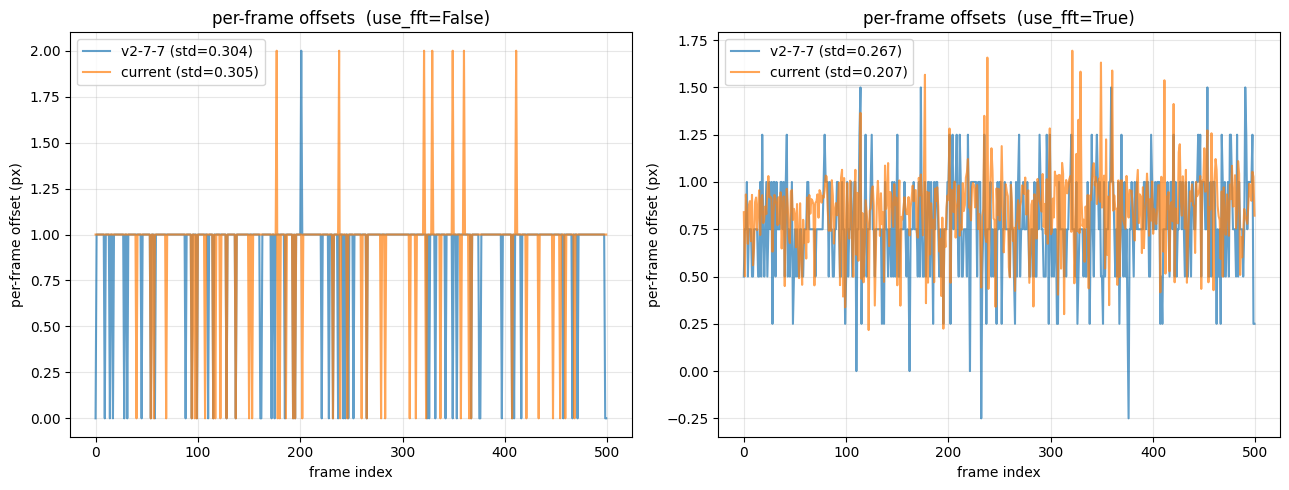

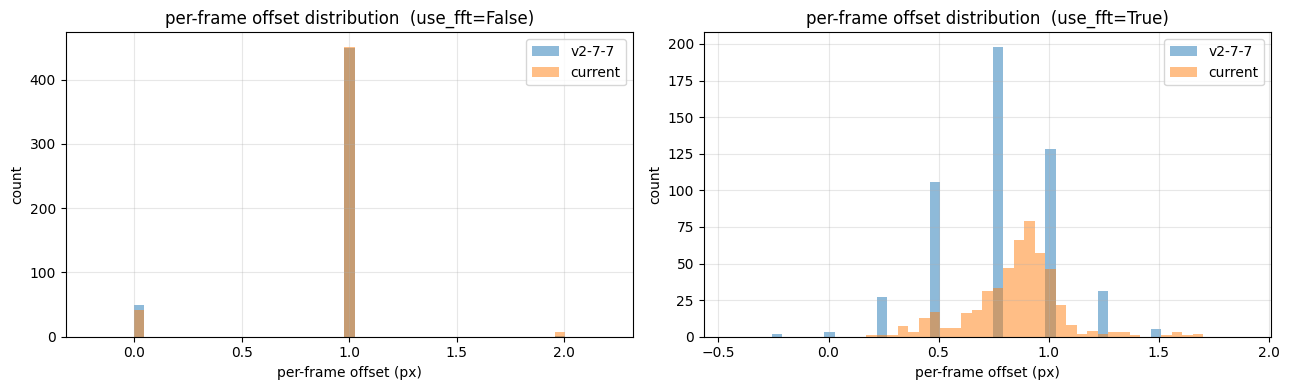

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5))
for ax, use_fft in zip(axs, USE_FFT):
    o = np.asarray(old_pf[use_fft]["per_frame_offsets"])
    n = np.asarray(new_pf[use_fft]["per_frame_offsets"])
    ax.plot(o, label=f"v2-7-7 (std={o.std():.3f})", color="C0", alpha=0.7)
    ax.plot(n, label=f"current (std={n.std():.3f})", color="C1", alpha=0.7)
    ax.set_xlabel("frame index")
    ax.set_ylabel("per-frame offset (px)")
    ax.set_title(f"per-frame offsets  (use_fft={use_fft})")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout(); plt.show()

fig, axs = plt.subplots(1, 2, figsize=(13, 4))
for ax, use_fft in zip(axs, USE_FFT):
    o = np.asarray(old_pf[use_fft]["per_frame_offsets"])
    n = np.asarray(new_pf[use_fft]["per_frame_offsets"])
    rng = (min(o.min(), n.min()) - 0.2, max(o.max(), n.max()) + 0.2)
    bins = np.linspace(*rng, 50)
    ax.hist(o, bins=bins, alpha=0.5, label="v2-7-7", color="C0")
    ax.hist(n, bins=bins, alpha=0.5, label="current", color="C1")
    ax.set_xlabel("per-frame offset (px)")
    ax.set_ylabel("count")
    ax.set_title(f"per-frame offset distribution  (use_fft={use_fft})")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout(); plt.show()